In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [2]:
a = torch.rand(2, 3, 5, 4)
b = torch.rand(4, 6)
(a @ b).shape

torch.Size([2, 3, 5, 6])

In [7]:
import math
class RoPE(nn.Module):
    def __init__(self, d_h, T_m=2048, base=10000):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, d_h, 2).float() / d_h))
        pos = torch.arange(T_m).float() # t_m, 
        freqs = torch.outer(pos, inv_freq) # t_m, d_h//2
        cos = freqs.cos()
        sin = freqs.sin()
        rot = torch.zeros(T_m, d_h, d_h)
        for t in range(T_m):
            for i in range(d_h//2):
                angle = t * base**(-2*i/d_h)
                rot[t, 2*i, 2*i] = math.cos(angle)
                rot[t, 2*i, 2*i+1] = math.sin(angle)
                rot[t, 2*i+1, 2*i] = -math.sin(angle)
                rot[t, 2*i+1, 2*i+1] = math.cos(angle)

        self.register_buffer("rot", rot, persistent=False)
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
    def _rotate_half(self, x):
        x_even = x[..., 0::2]
        x_odd = x[..., 1::2]
        return torch.stack((-x_odd, x_even), dim=-1).flatten(-2)
    def forward(self, x: torch.Tensor):
        # (b, t, n_h, d_h)
        # t = x.shape[1]
        # cos = self.cos[:t]
        # sin = self.sin[:t]
        # cos = torch.repeat_interleave(cos, 2, dim=-1)[None, :, None, :]
        # sin = torch.repeat_interleave(sin, 2, dim=-1)[None, :, None, :]
        # return (x * cos + self._rotate_half(x) * sin)
        # currently uses hadamard multiplication (optimized for this problem)
        # to write implementation using matrix multiply
        b, t, n_h, d_h = x.shape
        x = x.permute(0, 2, 1, 3) # b, n_h, t, d_h
        x = x.unsqueeze(-2) # b, n_h, t, 1, d_h
        r = self.rot[:t, :, :] # t, d_h, d_h
        res = (x @ r).squeeze(-2) # b, n_h, t, d_h
        return res.permute(0, 2, 1, 3).contiguous() # b, t, n_h, d_h

In [8]:
inv_freq = 1.0 / (10000 ** (torch.arange(0, 4, 2).float() / 4))
inv_freq

tensor([1.0000, 0.0100])

In [9]:
pos = torch.arange(2).float()
pos

tensor([0., 1.])

In [10]:
freqs = torch.outer(pos, inv_freq)
cos = freqs.cos()
print(cos)
torch.repeat_interleave(cos, 2, dim=-1)[None, :, None, :][0, 1, :, :]

tensor([[1.0000, 1.0000],
        [0.5403, 0.9999]])


tensor([[0.5403, 0.5403, 0.9999, 0.9999]])

In [11]:
x = torch.rand(1, 2, 3, 4)
print(x.shape)

torch.Size([1, 2, 3, 4])


In [12]:
x_even = x[..., 0::2]
x_odd = x[..., 1::2]
x_even.shape

torch.Size([1, 2, 3, 2])

In [13]:
x

tensor([[[[0.5723, 0.3705, 0.7069, 0.3096],
          [0.1764, 0.8649, 0.2726, 0.3998],
          [0.0026, 0.8346, 0.8788, 0.6822]],

         [[0.1514, 0.0065, 0.0939, 0.8729],
          [0.7401, 0.9208, 0.7619, 0.6265],
          [0.4951, 0.1197, 0.0716, 0.0323]]]])

In [14]:
x_even

tensor([[[[0.5723, 0.7069],
          [0.1764, 0.2726],
          [0.0026, 0.8788]],

         [[0.1514, 0.0939],
          [0.7401, 0.7619],
          [0.4951, 0.0716]]]])

In [15]:
torch.stack((-x_odd, x_even), dim=-1)

tensor([[[[[-0.3705,  0.5723],
           [-0.3096,  0.7069]],

          [[-0.8649,  0.1764],
           [-0.3998,  0.2726]],

          [[-0.8346,  0.0026],
           [-0.6822,  0.8788]]],


         [[[-0.0065,  0.1514],
           [-0.8729,  0.0939]],

          [[-0.9208,  0.7401],
           [-0.6265,  0.7619]],

          [[-0.1197,  0.4951],
           [-0.0323,  0.0716]]]]])

In [16]:
torch.stack((-x_odd, x_even), dim=-1).flatten(-2)

tensor([[[[-0.3705,  0.5723, -0.3096,  0.7069],
          [-0.8649,  0.1764, -0.3998,  0.2726],
          [-0.8346,  0.0026, -0.6822,  0.8788]],

         [[-0.0065,  0.1514, -0.8729,  0.0939],
          [-0.9208,  0.7401, -0.6265,  0.7619],
          [-0.1197,  0.4951, -0.0323,  0.0716]]]])

In [17]:
# attention calculation and kv cache

practice ends

In [19]:
import json

# Language configuration - change these to work with different language pairs
SRC_COL = 'de'  # Source language column
TGT_COL = 'en'  # Target language column

def load_jsonl(path, src_col=SRC_COL, tgt_col=TGT_COL):
    data = {src_col: [], tgt_col: []}
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
        for line in lines:
            d = json.loads(line)
            data[src_col].append(d[src_col])
            data[tgt_col].append(d[tgt_col])
    return data

train_df = pd.DataFrame(load_jsonl("train.jsonl", SRC_COL, TGT_COL))
val_df = pd.DataFrame(load_jsonl("val.jsonl", SRC_COL, TGT_COL))
test_df = pd.DataFrame(load_jsonl("test.jsonl", SRC_COL, TGT_COL))

In [ ]:
train_df.head()

,de,en
0,Zwei junge weiße Männer sind im Freien in der ...,"Two young, White males are outside near many b..."
1,Mehrere Männer mit Schutzhelmen bedienen ein A...,Several men in hard hats are operating a giant...
2,Ein kleines Mädchen klettert in ein Spielhaus ...,A little girl climbing into a wooden playhouse.
3,Ein Mann in einem blauen Hemd steht auf einer ...,A man in a blue shirt is standing on a ladder ...
4,Zwei Männer stehen am Herd und bereiten Essen zu.,Two men are at the stove preparing food.


In [20]:
print(len(train_df), len(val_df), len(test_df))

29000 1014 1000


In [21]:
from collections import Counter
def preprocess(text):
    text = text.lower()
    return text.split()
MAX_LEN = 32
PAD_IDX = 0 
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3
class Vocab:
    def __init__(self, texts):
        c = Counter()
        for t in texts:
            c.update(preprocess(t))
        self.word2idx = {"<pad>": PAD_IDX, "<sos>": SOS_IDX, "<eos>": EOS_IDX, "<unk>": UNK_IDX}
        count = len(self.word2idx)
        self.idx2word = {PAD_IDX: "<pad>", SOS_IDX: "<sos>", EOS_IDX: "<eos>", UNK_IDX: "<unk>"}
        for word, _ in sorted(c.items(), key=lambda item: (-item[1], item[0])):
            self.word2idx[word] = count
            self.idx2word[count] = word
            count += 1
    def __len__(self):
        return len(self.word2idx)
    def encode(self, text):
        return [self.word2idx.get(t, UNK_IDX) for t in preprocess(text)]
    def decode(self, ids):
        out = []
        for i in ids:
            tok = self.idx2word[int(i)]
            if tok == "<eos>":
                break
            if tok not in ("<pad>", "<sos>"):
                out.append(tok)
        return " ".join(out)

In [22]:
src_vocab = Vocab(train_df[SRC_COL].values)
tgt_vocab = Vocab(train_df[TGT_COL].values)

In [23]:
print(len(src_vocab), len(tgt_vocab))

24333 14450


In [24]:
text = "A large crowd"
src_vocab.encode(text)[:5]

[2085, 3, 3]

In [25]:
x = [13, 2102,   42,   56,   10,    6,   75,  812,  109,    5,    6,
         2039,    5,    6,  804,  481,   76]
y = [1] + x + [2]
c = len(y)
y = y + [0] * (32 - c)
print(len(y))

32


In [26]:
class TranlationDataset(torch.utils.data.Dataset):
    def __init__(self, frame, src_vocab, tgt_vocab, src_col=SRC_COL, tgt_col=TGT_COL):
        # print("init")
        self.frame = frame.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.src_col = src_col
        self.tgt_col = tgt_col
    def __len__(self):
        # print("len")
        return len(self.frame)
    def __getitem__(self, index):
        # print("getitem")
        r = self.frame.iloc[index]
        src_list = [self.src_vocab.word2idx["<sos>"]] + self.src_vocab.encode(r[self.src_col])[:MAX_LEN-2] + [self.src_vocab.word2idx["<eos>"]]
        # src_len = len(src_list)
        # src_list += [self.src_vocab.word2idx["<pad>"]] * (MAX_LEN - src_len)
        src = torch.tensor(
            src_list,
            dtype=torch.long
        )
        tgt_list = [self.tgt_vocab.word2idx["<sos>"]] + self.tgt_vocab.encode(r[self.tgt_col])[:MAX_LEN-2] + [self.tgt_vocab.word2idx["<eos>"]]
        # tgt_len = len(tgt_list)
        # tgt_list += [self.tgt_vocab.word2idx["<pad>"]] * (MAX_LEN - tgt_len)
        tgt = torch.tensor(
            tgt_list,
            dtype=torch.long
        )
        # print(src)
        # print(tgt)
        return src, tgt

In [27]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    srcs, tgts = zip(*batch)

    src = pad_sequence(
        srcs,
        batch_first=True,
        padding_value=PAD_IDX
    )

    tgt = pad_sequence(
        tgts,
        batch_first=True,
        padding_value=PAD_IDX
    )

    # Lengths are retained for compatibility with the original notebook.
    lengths = torch.tensor(
        [len(x) for x in srcs],
        dtype=torch.long
    )

    return src, lengths, tgt


In [28]:
BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(TranlationDataset(train_df, src_vocab, tgt_vocab, SRC_COL, TGT_COL), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = torch.utils.data.DataLoader(TranlationDataset(val_df, src_vocab, tgt_vocab, SRC_COL, TGT_COL), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=torch.cuda.is_available())

In [29]:
x, l, y = next(iter(train_loader))
print(x.shape, l[:5].tolist(), y.shape)

torch.Size([64, 25]) [24, 15, 12, 13, 11] torch.Size([64, 24])


In [30]:
x

tensor([[   1,    7, 4232,  ..., 2661,    2,    0],
        [   1,    7,   33,  ...,    0,    0,    0],
        [   1,    7,   33,  ...,    0,    0,    0],
        ...,
        [   1,    4,   11,  ...,    0,    0,    0],
        [   1,    4,  107,  ...,    0,    0,    0],
        [   1,    4,   11,  ...,    0,    0,    0]])

In [31]:
y

tensor([[   1,    4,  866,  ...,    0,    0,    0],
        [   1,    4,   36,  ...,    0,    0,    0],
        [   1,   36,   11,  ...,    0,    0,    0],
        ...,
        [   1,    4,    8,  ...,    0,    0,    0],
        [   1,    4, 9715,  ...,    0,    0,    0],
        [   1,    4,    8,  ...,    0,    0,    0]])

In [32]:
import math


class SinosoidalPosEmb(nn.Module):
    """Classic sinusoidal positional encoding.

    Input/output shape: [B, T, D]
    """

    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()

        position = torch.arange(
            max_len, dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * -(math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer(
            "pe",
            pe.unsqueeze(0),
            persistent=False
        )

    def forward(self, x):
        return self.pe[:, :x.size(1)]


class Encoder(nn.Module):
    """Transformer encoder using PyTorch's nn.TransformerEncoder API."""

    def __init__(
        self,
        input_dim,
        d_model=256,
        num_heads=8,
        d_ff=1024,
        n_enc=4,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.emb = nn.Embedding(
            input_dim,
            d_model,
            padding_idx=PAD_IDX
        )

        self.pe = SinosoidalPosEmb(
            d_model,
            MAX_LEN
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_enc,
            norm=nn.LayerNorm(d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_key_padding_mask=None):
        """
        src: [B, S]
        src_key_padding_mask: [B, S], True means PAD
        returns: [B, S, D]
        """

        x = self.emb(src) * math.sqrt(self.d_model)
        x = x + self.pe(x)
        x = self.dropout(x)

        return self.encoder(
            x,
            src_key_padding_mask=src_key_padding_mask
        )


class Decoder(nn.Module):
    """Transformer decoder using PyTorch's nn.TransformerDecoder API."""

    def __init__(
        self,
        output_dim,
        d_model=256,
        num_heads=8,
        d_ff=1024,
        n_dec=4,
        dropout=0.1
    ):
        super().__init__()

        self.output_dim = output_dim
        self.d_model = d_model

        self.emb = nn.Embedding(
            output_dim,
            d_model,
            padding_idx=PAD_IDX
        )

        self.pe = SinosoidalPosEmb(
            d_model,
            MAX_LEN
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=n_dec,
            norm=nn.LayerNorm(d_model)
        )

        self.dropout = nn.Dropout(dropout)

        # Weight tying: output projection shares weights with target embedding.
        self.fc_out = nn.Linear(
            d_model,
            output_dim,
            bias=False
        )
        self.fc_out.weight = self.emb.weight

    def forward(
        self,
        tgt,
        memory,
        tgt_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None
    ):
        """
        tgt: [B, T]
        memory: [B, S, D]

        tgt_mask: [T, T], causal attention mask
        tgt_key_padding_mask: [B, T], True means PAD
        memory_key_padding_mask: [B, S], True means PAD

        returns: [B, T, V]
        """

        x = self.emb(tgt) * math.sqrt(self.d_model)
        x = x + self.pe(x)
        x = self.dropout(x)

        x = self.decoder(
            tgt=x,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )

        return self.fc_out(x)


class TransformerModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    @staticmethod
    def make_causal_mask(length, device):
        """
        PyTorch Transformer causal mask: [T, T].

        False = attention allowed
        True  = attention blocked
        """

        # Bool attn_mask: True means the position is blocked.
        return torch.triu(
            torch.ones(length, length, dtype=torch.bool, device=device),
            diagonal=1
        )

    @staticmethod
    def make_padding_mask(tokens):
        """[B, T], True for PAD positions."""
        return tokens.eq(PAD_IDX)

    def encode(self, src):
        src_key_padding_mask = self.make_padding_mask(src)

        return self.encoder(
            src,
            src_key_padding_mask=src_key_padding_mask
        )

    def forward(self, src, lengths, tgt):
        # lengths are no longer required by Transformer attention, but are
        # retained in the signature so the existing notebook calls work.
        del lengths

        src_key_padding_mask = self.make_padding_mask(src)
        tgt_key_padding_mask = self.make_padding_mask(tgt)

        memory = self.encoder(
            src,
            src_key_padding_mask=src_key_padding_mask
        )

        tgt_mask = self.make_causal_mask(
            tgt.size(1),
            tgt.device
        )

        return self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )


def initialize_transformer_weights(module):
    """Xavier-style initialization for the Transformer."""

    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(module, nn.Embedding):
        nn.init.normal_(
            module.weight,
            mean=0.0,
            std=0.02
        )

        if module.padding_idx is not None:
            with torch.no_grad():
                module.weight[module.padding_idx].zero_()


In [33]:
encoder = Encoder(input_dim=len(src_vocab))
decoder = Decoder(output_dim=len(tgt_vocab))
model = TransformerModel(encoder, decoder).to(DEVICE)

for src, lengths, tgt in train_loader:
    tgt_in = tgt[:, :-1]
    logits = model(src.to(DEVICE), lengths.to(DEVICE), tgt_in.to(DEVICE))

    print("src:   ", tuple(src.shape))
    print("tgt_in:", tuple(tgt_in.shape))
    print("logits:", tuple(logits.shape))
    break


C:\Users\shubh\AppData\Local\Temp\ipykernel_5772\3861263970.py:73: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


src:    (64, 23)
tgt_in: (64, 20)
logits: (64, 20, 14450)


In [34]:
src, lengths, tgt = next(iter(train_loader))
print(tgt.shape)

torch.Size([64, 27])


In [35]:
print(tgt)

tensor([[   1,    4,    8,  ...,    0,    0,    0],
        [   1,    4,    8,  ...,    0,    0,    0],
        [   1,    6,    8,  ...,    0,    0,    0],
        ...,
        [   1,    4,   46,  ...,    0,    0,    0],
        [   1,   18, 1708,  ...,    0,    0,    0],
        [   1,    4,   36,  ...,    0,    0,    0]])


In [36]:
tgt[:, :-1]

tensor([[   1,    4,    8,  ...,    0,    0,    0],
        [   1,    4,    8,  ...,    0,    0,    0],
        [   1,    6,    8,  ...,    0,    0,    0],
        ...,
        [   1,    4,   46,  ...,    0,    0,    0],
        [   1,   18, 1708,  ...,    0,    0,    0],
        [   1,    4,   36,  ...,    0,    0,    0]])

In [37]:
tgt[:, 1:].reshape(-1)

tensor([4, 8, 9,  ..., 0, 0, 0])

In [38]:
from tqdm import tqdm


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for src, lengths, tgt in tqdm(loader, desc="Calculating train loss..."):
        src = src.to(DEVICE, non_blocking=True)
        lengths = lengths.to(DEVICE, non_blocking=True)
        tgt = tgt.to(DEVICE, non_blocking=True)

        # Teacher forcing:
        # decoder input = <sos> y1 y2 ... y(n-1)
        # target        = y1   y2 ... yn <eos>
        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        optimizer.zero_grad(set_to_none=True)

        logits = model(src, lengths, tgt_in)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_out.reshape(-1)
        )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.detach().item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    for src, lengths, tgt in tqdm(loader, desc="Calculating val loss..."):
        src = src.to(DEVICE, non_blocking=True)
        lengths = lengths.to(DEVICE, non_blocking=True)
        tgt = tgt.to(DEVICE, non_blocking=True)

        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        logits = model(src, lengths, tgt_in)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_out.reshape(-1)
        )

        total_loss += loss.detach().item()

    return total_loss / max(len(loader), 1)


In [39]:
# Teacher-forcing sanity check
#
# During training, position t receives tokens only up to y_{t-1}
# and must predict y_t. At inference, this is exactly what happens.

src0, lengths0, tgt0 = next(iter(train_loader))
print("Full target shape:   ", tuple(tgt0.shape))
print("Decoder input shape: ", tuple(tgt0[:, :-1].shape))
print("Prediction shape:    ", tuple(tgt0[:, 1:].shape))
print("Shifted-target training is enabled.")


Full target shape:    (64, 24)
Decoder input shape:  (64, 23)
Prediction shape:     (64, 23)
Shifted-target training is enabled.


C:\Users\shubh\AppData\Local\Temp\ipykernel_5772\3861263970.py:73: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Calculating val loss...: 100%|██████████| 16/16 [00:00<00:00, 64.97it/s]


Epoch 01 | train_loss=5.5474 | val_loss=4.5698 | lr=3.00e-04
  -> best checkpoint saved (4.5698)


Calculating val loss...: 100%|██████████| 16/16 [00:00<00:00, 65.53it/s]


Epoch 02 | train_loss=4.3119 | val_loss=3.9731 | lr=3.00e-04
  -> best checkpoint saved (3.9731)


Calculating val loss...: 100%|██████████| 16/16 [00:00<00:00, 61.35it/s]


Epoch 03 | train_loss=3.8445 | val_loss=3.6738 | lr=3.00e-04
  -> best checkpoint saved (3.6738)


Calculating val loss...: 100%|██████████| 16/16 [00:00<00:00, 63.97it/s]


Epoch 04 | train_loss=3.5424 | val_loss=3.4964 | lr=3.00e-04
  -> best checkpoint saved (3.4964)


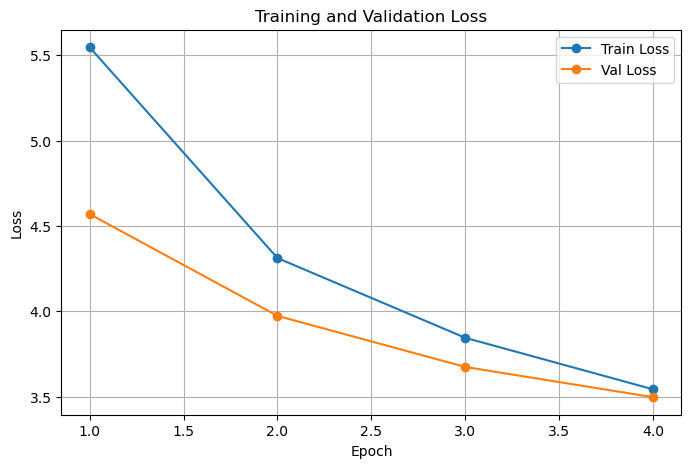

In [41]:
import matplotlib.pyplot as plt

model = TransformerModel(
    Encoder(len(src_vocab)),
    Decoder(len(tgt_vocab))
).to(DEVICE)

model.apply(initialize_transformer_weights)

# Keep padding embeddings at zero after tied output-weight initialization.
with torch.no_grad():
    model.encoder.emb.weight[PAD_IDX].zero_()
    model.decoder.emb.weight[PAD_IDX].zero_()

# A slightly larger LR with AdamW works better for this transformer than
# the original 1e-4 Adam setup.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=0.1
)

# Reduce LR once validation loss plateaus.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

train_losses = []
val_losses = []

CKPT_PATH = "best_model.pt"
best_val_loss = float("inf")
patience = 6
epochs_without_improvement = 0
NUM_EPOCHS = 4

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"lr={current_lr:.2e}"
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_loss": val_loss,
        }, CKPT_PATH)

        print(f"  -> best checkpoint saved ({best_val_loss:.4f})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

if "optimizer_state_dict" in checkpoint:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
if "scheduler_state_dict" in checkpoint:
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

print(
    f"Loaded model from epoch {checkpoint['epoch']} "
    f"with val_loss {checkpoint['val_loss']:.4f}"
)


Loaded model from epoch 4 with val_loss 3.4964


In [43]:
# Useful diagnostics: these often reveal whether poor BLEU is caused by
# truncation or excessive unknown tokens rather than the Transformer itself.

def avg_token_length(frame, column):
    vals = [len(preprocess(x)) for x in frame[column]]
    return float(np.mean(vals))

print(f"Average source tokens: {avg_token_length(train_df, SRC_COL):.2f}")
print(f"Average target tokens: {avg_token_length(train_df, TGT_COL):.2f}")
print(f"MAX_LEN: {MAX_LEN}")

src_trunc = sum(len(preprocess(x)) >= MAX_LEN - 2 for x in test_df[SRC_COL])
tgt_trunc = sum(len(preprocess(x)) >= MAX_LEN - 2 for x in test_df[TGT_COL])

print(f"Test source examples truncated: {src_trunc}/{len(test_df)}")
print(f"Test target examples truncated: {tgt_trunc}/{len(test_df)}")


Average source tokens: 11.12
Average target tokens: 11.90
MAX_LEN: 32
Test source examples truncated: 1/1000
Test target examples truncated: 2/1000


In [44]:
import torch.nn.functional as F


def make_src_padding_mask(src):
    """Return [B, S] mask where True means PAD."""
    return src.eq(PAD_IDX)


def make_causal_mask(tgt_len, device):
    """Return PyTorch's [T, T] causal attention mask."""
    # Bool attn_mask: True means the position is blocked.
    return torch.triu(
        torch.ones(tgt_len, tgt_len, dtype=torch.bool, device=device),
        diagonal=1
    )


@torch.no_grad()
def beam_search_decode(
    model,
    src,
    src_vocab,
    tgt_vocab,
    beam_width=5,
    max_len=MAX_LEN,
    length_penalty_alpha=0.6,
    device=DEVICE
):
    """Beam search for a SINGLE source sentence."""

    del src_vocab, tgt_vocab

    model.eval()
    src = src.to(device)

    # Encode once.
    memory = model.encode(src)
    memory_key_padding_mask = make_src_padding_mask(src)

    beams = [([SOS_IDX], 0.0, False)]

    def normalized_score(score, tokens):
        length = max(len(tokens) - 1, 1)
        penalty = (
            (5.0 + length) ** length_penalty_alpha
            / 6.0 ** length_penalty_alpha
        )
        return score / penalty

    for _ in range(max_len - 1):
        candidates = []

        if all(finished for _, _, finished in beams):
            break

        for tokens, score, finished in beams:
            if finished:
                candidates.append((tokens, score, True))
                continue

            tgt = torch.tensor(
                [tokens],
                dtype=torch.long,
                device=device
            )

            tgt_mask = make_causal_mask(
                tgt.size(1),
                device
            )
            tgt_key_padding_mask = tgt.eq(PAD_IDX)

            logits = model.decoder(
                tgt=tgt,
                memory=memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_key_padding_mask,
                memory_key_padding_mask=memory_key_padding_mask
            )

            log_probs = F.log_softmax(
                logits[0, -1],
                dim=-1
            )

            k = min(beam_width * 2, log_probs.numel())
            top_log_probs, top_ids = torch.topk(
                log_probs,
                k=k
            )

            for lp, idx in zip(
                top_log_probs.tolist(),
                top_ids.tolist()
            ):
                new_tokens = tokens + [idx]
                new_score = score + lp
                new_finished = idx == EOS_IDX
                candidates.append(
                    (new_tokens, new_score, new_finished)
                )

        candidates.sort(
            key=lambda item: normalized_score(
                item[1],
                item[0]
            ),
            reverse=True
        )

        beams = candidates[:beam_width]

    beams.sort(
        key=lambda item: normalized_score(
            item[1],
            item[0]
        ),
        reverse=True
    )

    return [
        (tokens, normalized_score(score, tokens))
        for tokens, score, _ in beams
    ]


In [45]:
def ids_to_sentence(ids, vocab):
    """Convert a list/tensor of token ids to a human-readable string using vocab.decode."""
    return vocab.decode(ids)

# pick a training example
example_idx = 0
example_row = train_df.iloc[example_idx]
src_text = example_row[SRC_COL]
ref_text = example_row[TGT_COL]

src_ids = [SOS_IDX] + src_vocab.encode(src_text)[:MAX_LEN - 2] + [EOS_IDX]
src_tensor = torch.tensor([src_ids], dtype=torch.long)

beams = beam_search_decode(model, src_tensor, src_vocab, tgt_vocab,
                            beam_width=5, max_len=MAX_LEN, length_penalty_alpha=0.6)

print(f"Source ({SRC_COL}):    {src_text}")
print(f"Reference ({TGT_COL}): {ref_text}\n")
print("Top beams:")
for rank, (tokens, score) in enumerate(beams, start=1):
    sentence = ids_to_sentence(tokens, tgt_vocab)
    print(f"  {rank}. score={score:.4f}  ->  {sentence}")

Source (de):    Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
Reference (en): Two young, White males are outside near many bushes.

Top beams:
  1. score=-4.6629  ->  two young white men are outside near some sort of water.
  2. score=-5.7096  ->  two young white men are gathered outside near some sort of water.
  3. score=-5.9839  ->  two young white men are outside near some some sort of water.
  4. score=-7.5049  ->  two young white men are gathered outside near some sort of six water.
  5. score=-7.5293  ->  two young white men are gathered outside near some sort of some water.


In [46]:
from collections import Counter

def get_ngrams(tokens, n):
    """Return a Counter of n-grams (as tuples) from a token list."""
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def corpus_bleu_score(references, hypotheses, max_n=4, smooth_eps=1e-9):
    """
    references: list[list[str]]  - one reference token list per example
    hypotheses: list[list[str]]  - one hypothesis token list per example
    Computes corpus-level BLEU-max_n with additive (epsilon) smoothing on n-gram precision,
    and standard brevity penalty.
    """
    precisions = []
    for n in range(1, max_n + 1):
        match_count = 0
        total_count = 0
        for ref, hyp in zip(references, hypotheses):
            ref_ngrams = get_ngrams(ref, n)
            hyp_ngrams = get_ngrams(hyp, n)
            overlap = hyp_ngrams & ref_ngrams  # min counts per ngram
            match_count += sum(overlap.values())
            total_count += max(sum(hyp_ngrams.values()), 0)
        # smoothed precision to avoid zero when match_count == 0
        precision = (match_count + smooth_eps) / (total_count + smooth_eps)
        precisions.append(precision)

    # geometric mean of n-gram precisions
    log_precision_sum = sum(math.log(p) for p in precisions) / max_n
    geo_mean = math.exp(log_precision_sum)

    ref_len = sum(len(r) for r in references)
    hyp_len = sum(len(h) for h in hypotheses)
    if hyp_len == 0:
        brevity_penalty = 0.0
    elif hyp_len > ref_len:
        brevity_penalty = 1.0
    else:
        brevity_penalty = math.exp(1 - ref_len / max(hyp_len, 1))

    bleu = brevity_penalty * geo_mean
    return bleu * 100  # as percentage

# --- Evaluate over a test subset ---
N_EVAL = 100  # subset size (k)
eval_df = test_df.iloc[:N_EVAL]

references = []
hypotheses = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    src_text, ref_text = row[SRC_COL], row[TGT_COL]
    src_ids = [SOS_IDX] + src_vocab.encode(src_text)[:MAX_LEN - 2] + [EOS_IDX]
    src_tensor = torch.tensor([src_ids], dtype=torch.long)

    beams = beam_search_decode(model, src_tensor, src_vocab, tgt_vocab,
                                beam_width=5, max_len=MAX_LEN, length_penalty_alpha=0.6)
    best_tokens, _ = beams[0]

    hyp_sentence = ids_to_sentence(best_tokens, tgt_vocab)
    references.append(preprocess(ref_text))     # reuse the notebook's own tokenizer
    hypotheses.append(hyp_sentence.split())

bleu = corpus_bleu_score(references, hypotheses, max_n=4)
print(f"Corpus BLEU on {N_EVAL} test examples: {bleu:.2f}")

100%|██████████| 100/100 [00:32<00:00,  3.08it/s]

Corpus BLEU on 100 test examples: 25.06


In [47]:
N_QUAL = 5
qual_df = test_df.iloc[:N_QUAL]

for i, row in qual_df.iterrows():
    src_text, ref_text = row[SRC_COL], row[TGT_COL]
    src_ids = [SOS_IDX] + src_vocab.encode(src_text)[:MAX_LEN - 2] + [EOS_IDX]
    src_tensor = torch.tensor([src_ids], dtype=torch.long)

    beams = beam_search_decode(model, src_tensor, src_vocab, tgt_vocab,
                                beam_width=5, max_len=MAX_LEN, length_penalty_alpha=0.6)

    print(f"Example {i}")
    print(f"  Source ({SRC_COL}):      {src_text}")
    print(f"  Reference ({TGT_COL}):   {ref_text}")
    print("  Top predictions:")
    for rank, (tokens, score) in enumerate(beams, start=1):
        pred_sentence = ids_to_sentence(tokens, tgt_vocab)
        print(f"    {rank}. (score={score:.4f}) {pred_sentence}")
    print()

Example 0
  Source (de):      Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
  Reference (en):   A man in an orange hat starring at something.
  Top predictions:
    1. (score=-8.4211) a man with an orange hat is using something to a wooden fence.
    2. (score=-8.7552) a man with an orange hat is using something to a wooden machine.
    3. (score=-8.8985) a man with an orange hat is using something to a wooden structure.
    4. (score=-8.9695) a man with an orange hat is using something to a wooden bus.
    5. (score=-9.8472) a man with an orange hat is using something to a wooden wooden fence.

Example 1
  Source (de):      Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
  Reference (en):   A Boston Terrier is running on lush green grass in front of a white fence.
  Top predictions:
    1. (score=-6.7418) a gymnast is walking through the grass in front of a white fence.
    2. (score=-6.7470) a gymnast is running through the grass in front of a whi